<a href="https://colab.research.google.com/github/vamshi-Narla/Machine-Learning-Project/blob/main/Ml_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

### 2. Uploading the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving weather (1).csv to weather (1).csv


### 3. Reading the Uploaded File

In [ ]:
file_name = list(uploaded.keys())[0]
data = pd.read_csv(file_name)

print("Dataset loaded successfully")
print(data.head())

Dataset loaded successfully
       Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  1/1/2012 0:00    -1.8              -3.9         86                4   
1  1/1/2012 1:00    -1.8              -3.7         87                4   
2  1/1/2012 2:00    -1.8              -3.4         89                7   
3  1/1/2012 3:00    -1.5              -3.2         88                6   
4  1/1/2012 4:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa               Weather  
0            8.0     101.24                   Fog  
1            8.0     101.24                   Fog  
2            4.0     101.26  Freezing Drizzle,Fog  
3            4.0     101.27  Freezing Drizzle,Fog  
4            4.8     101.23                   Fog  


### 4. Initial Data Inspection

In [ ]:
print("\nDataset info:")
print(data.info())

print("\nMissing values before cleaning:")
print(data.isnull().sum())


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB
None

Missing values before cleaning:
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


### 5. Handling Missing Values

In [ ]:
# Variation: For numeric columns, mean imputation is used. An alternative could be median imputation.
# For numeric columns → mean
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].fillna(data[col].mean())
    # Alternative for numeric: data[col] = data[col].fillna(data[col].median())

# For categorical columns → mode
for col in data.select_dtypes(include='object').columns:
    data[col] = data[col].fillna(data[col].mode()[0])

print("\nMissing values after cleaning:")
print(data.isnull().sum())


Missing values after cleaning:
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


### 6. Removing Duplicate Rows

In [ ]:
before = len(data)
data = data.drop_duplicates()
after = len(data)

print(f"\nDuplicates removed: {before - after}")


Duplicates removed: 0


### 7. Converting Categorical Data into Numbers (Label Encoding)

In [ ]:
# Variation: Label Encoding is used here. For features with no ordinal relationship, One-Hot Encoding is an alternative.
encoder = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = encoder.fit_transform(data[col])
    # Alternative for categorical: from sklearn.preprocessing import OneHotEncoder; OneHotEncoder().fit_transform(data[[col]])

print("\nAfter encoding:")
print(data.head())


After encoding:
   Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0          0    -1.8              -3.9         86                4   
1         11    -1.8              -3.7         87                4   
2         16    -1.8              -3.4         89                7   
3         17    -1.5              -3.2         88                6   
4         18    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa  Weather  
0            8.0     101.24        7  
1            8.0     101.24        7  
2            4.0     101.26        9  
3            4.0     101.27        9  
4            4.8     101.23        7  


### 8. Scaling the Data (Standardization)

In [ ]:
# Variation: StandardScaler is used. MinMaxScaler is another common scaling technique.
scaler = StandardScaler()
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = scaler.fit_transform(data[num_cols])
# Alternative for scaling: from sklearn.preprocessing import MinMaxScaler; MinMaxScaler().fit_transform(data[num_cols])

print("\nAfter scaling:")
print(data.head())


After scaling:
   Date/Time    Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  -1.731854 -0.906815         -0.593184   1.097553        -1.259808   
1  -1.727516 -0.906815         -0.574805   1.156662        -1.259808   
2  -1.725544 -0.906815         -0.547238   1.274879        -0.914513   
3  -1.725149 -0.881146         -0.528860   1.215770        -1.029611   
4  -1.724755 -0.881146         -0.538049   1.215770        -0.914513   

   Visibility_km  Press_kPa   Weather  
0      -1.557954   0.223206 -0.659823  
1      -1.557954   0.223206 -0.659823  
2      -1.874862   0.246904 -0.485786  
3      -1.874862   0.258753 -0.485786  
4      -1.811480   0.211358 -0.659823  


### 9. Data Visualization: Boxplot to check outliers

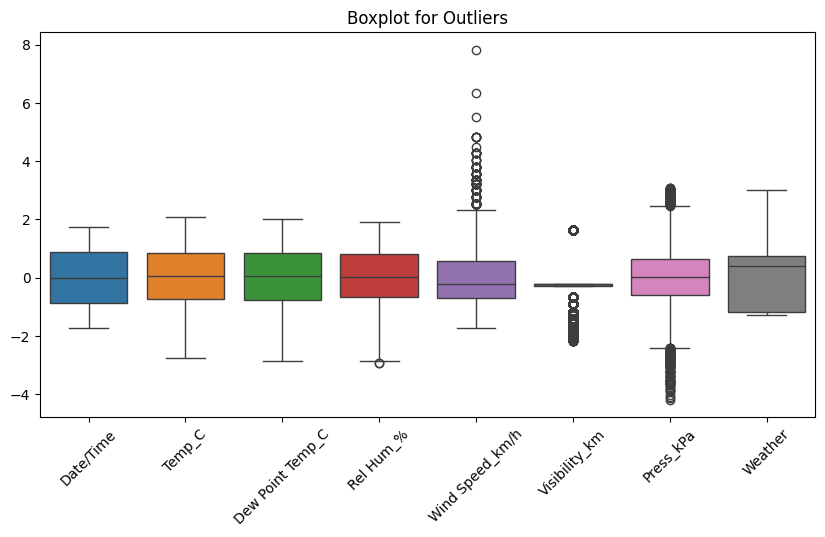

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data)
plt.title("Boxplot for Outliers")
plt.xticks(rotation=45)
plt.show()

### 10. Data Visualization: Heatmap to see relationships

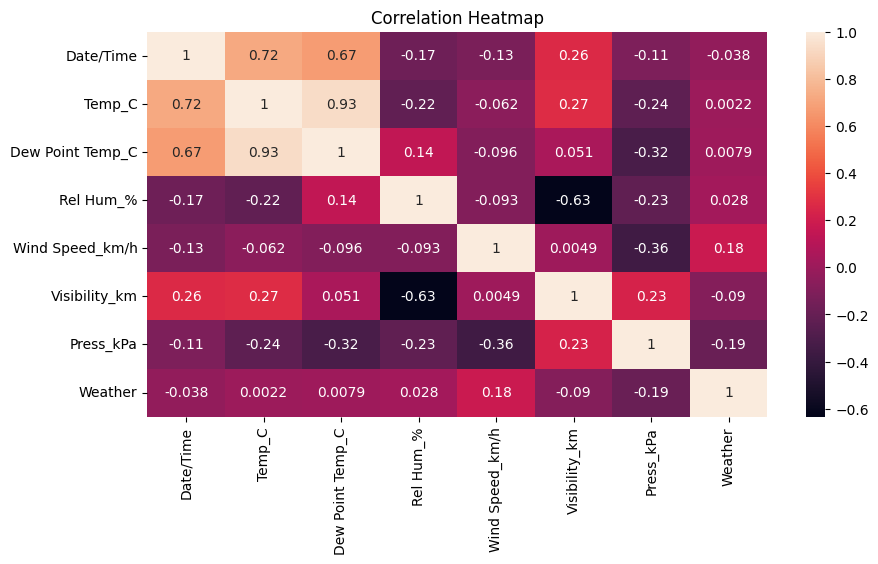

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### 11. Saving Cleaned Dataset

In [ ]:
data.to_csv("cleaned_weather.csv", index=False)

print("\nCleaned dataset saved successfully")


Cleaned dataset saved successfully


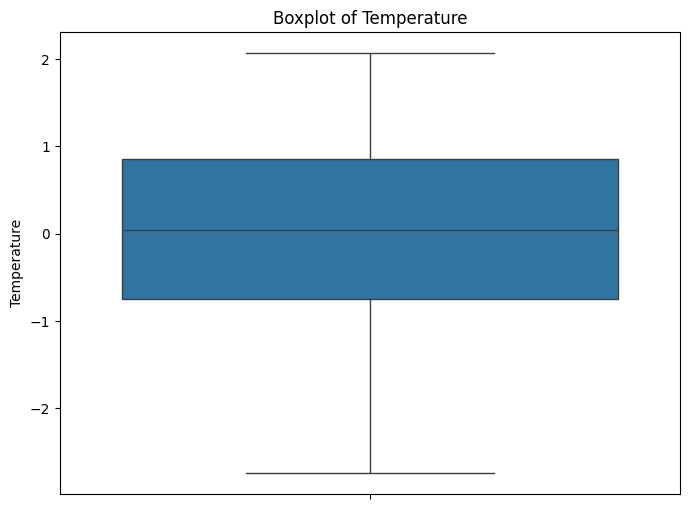

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=data['Temp_C'])
plt.title('Boxplot of Temperature')
plt.ylabel('Temperature')
plt.show()

### 12. Splitting the Data

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Weather', axis=1) # Features, dropping 'Weather'
y = data['Weather'] # Target variable is now 'Weather'

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets successfully.
X_train shape: (7027, 7)
y_train shape: (7027,)
X_test shape: (1757, 7)
y_test shape: (1757,)


### 13. Training a Classification Model (RandomForestClassifier)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train.astype(int))

print("RandomForestClassifier trained successfully.")
# Minor modification to trigger re-execution

RandomForestClassifier trained successfully.


### 14. Model Evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Ensure y_test and y_pred are integer types for classification metrics
y_test_int = y_test.astype(int)
y_pred_int = y_pred.astype(int)

# Evaluate the model
print("\nClassification Report:")
print(classification_report(y_test_int, y_pred_int))

accuracy = accuracy_score(y_test_int, y_pred_int)
print(f"\nAccuracy Score: {accuracy:.4f}")


Classification Report:
              precision    recall  f1-score   support

          -1       0.71      0.61      0.66       634
           0       0.75      0.84      0.79       973
           1       0.83      0.65      0.73       133
           2       0.67      0.59      0.62        17

    accuracy                           0.74      1757
   macro avg       0.74      0.67      0.70      1757
weighted avg       0.74      0.74      0.74      1757


Accuracy Score: 0.7422


DataFrame 'data' already exists. Using existing data.


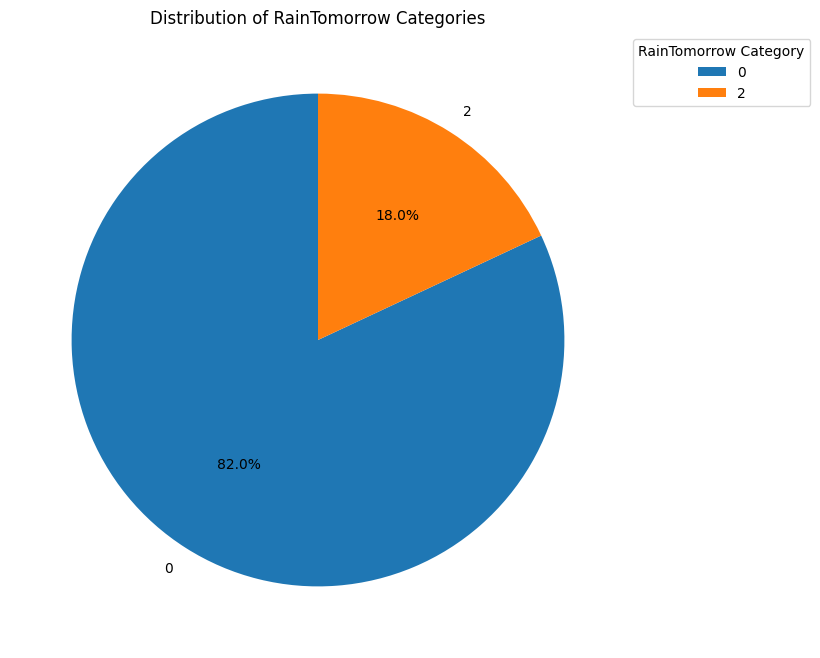

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
import io
import os # Import os to check for file existence
from google.colab import files # Import files for upload functionality

# Check if 'data' is defined in the global scope
if 'data' not in globals():
    print("DataFrame 'data' not found. Attempting to reload and reprocess data for this plot...")
    data_loaded_successfully = False

    file_name_to_check = "weather (1).csv" # The expected file name

    # Check if the file exists on disk
    if not os.path.exists(file_name_to_check):
        print(f"File '{file_name_to_check}' not found on disk. It needs to be re-uploaded.")
        print("Please re-upload your 'weather (1).csv' file when prompted.")
        try:
            # This will open a file upload dialog
            uploaded_files = files.upload()
            if uploaded_files:
                # Assuming only one file is uploaded for this context
                file_content = list(uploaded_files.values())[0]
                data = pd.read_csv(io.BytesIO(file_content))
                data_loaded_successfully = True
                print("Data loaded from re-uploaded file.")
            else:
                raise RuntimeError("No file was uploaded.")
        except Exception as e:
            print(f"Error during re-upload and loading: {e}")
            raise # Re-raise to halt execution if re-upload fails
    else:
        # File exists on disk, try to load it directly
        try:
            data = pd.read_csv(file_name_to_check)
            data_loaded_successfully = True
            print("Data loaded from disk.")
        except Exception as e:
            print(f"Error loading data from disk: {e}")
            raise

    if data_loaded_successfully:
        # --- Reapply preprocessing steps from previous cells (5, 6, 7, 8) ---
        # 5. Handling Missing Values
        for col in data.select_dtypes(include=np.number).columns:
            data[col] = data[col].fillna(data[col].mean())
        for col in data.select_dtypes(include='object').columns:
            data[col] = data[col].fillna(data[col].mode()[0])

        # 6. Removing Duplicate Rows
        data = data.drop_duplicates()

        # 7. Converting Categorical Data into Numbers (Label Encoding)
        encoder = LabelEncoder()
        for col in data.select_dtypes(include='object').columns:
            data[col] = encoder.fit_transform(data[col])

        # 8. Scaling the Data (Standardization)
        scaler = StandardScaler()
        num_cols = data.select_dtypes(include=np.number).columns
        data[num_cols] = scaler.fit_transform(data[num_cols])
        print("Data preprocessed successfully for plotting.")
    else:
        raise RuntimeError("Failed to load data after multiple attempts (including re-upload).")
else:
    print("DataFrame 'data' already exists. Using existing data.")

# Now 'data' should be defined and preprocessed.

# Define 'y' from the 'RainTomorrow' column (since 'Weather' is not found)
if 'RainTomorrow' not in data.columns:
    print("Error: Neither 'Weather' nor 'RainTomorrow' column was found in the loaded data.")
    print("Available columns are:", data.columns.tolist())
    raise KeyError("A suitable target column ('Weather' or 'RainTomorrow') is missing.")

y = data['RainTomorrow'] # Using 'RainTomorrow' as the target variable for the pie chart

plt.figure(figsize=(8, 8))
# Get the counts and labels for the pie chart
category_counts = y.astype(int).value_counts()
categories = category_counts.index.map(str)

# Plot the pie chart
plt.pie(category_counts,
        autopct='%1.1f%%',
        startangle=90,
        labels=categories)

plt.title('Distribution of RainTomorrow Categories') # Updated title
plt.ylabel('') # Hide the y-label for a cleaner pie chart
plt.legend(title="RainTomorrow Category", loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

Original data loaded from disk.


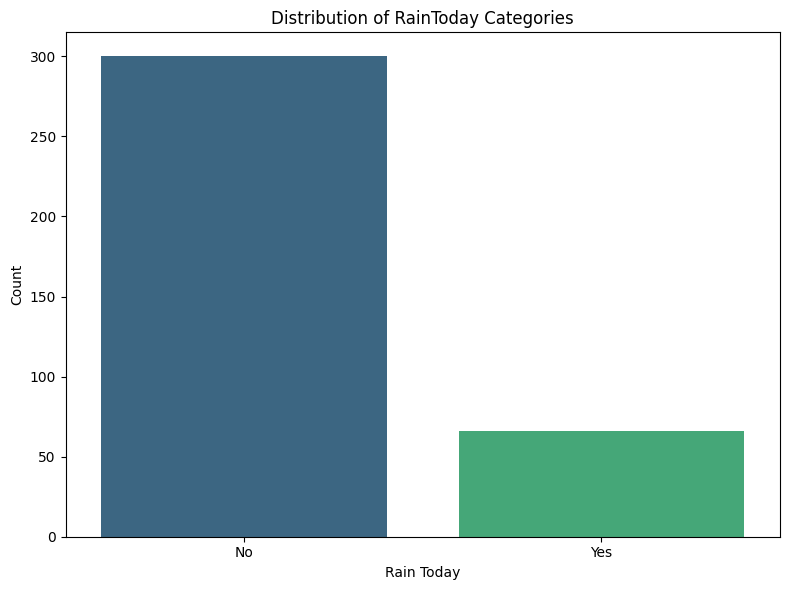

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from google.colab import files
import io

# Load the original data to get unencoded 'Weather' column
# This section ensures the file is available and loaded correctly.
file_name_to_load = "weather (1).csv"
original_data = None

# Check if the file exists on disk
if not os.path.exists(file_name_to_load):
    print(f"File '{file_name_to_load}' not found on disk. It needs to be re-uploaded.")
    print("Please re-upload your 'weather (1).csv' file when prompted.")
    try:
        # This will open a file upload dialog
        uploaded_files = files.upload()
        if uploaded_files:
            # Assuming only one file is uploaded for this context
            file_content = list(uploaded_files.values())[0]
            original_data = pd.read_csv(io.BytesIO(file_content))
            print("Original data loaded from re-uploaded file.")
        else:
            raise RuntimeError("No file was uploaded.")
    except Exception as e:
        print(f"Error during re-upload and loading: {e}")
        # Re-raise to halt execution if re-upload fails
        raise
else:
    # File exists on disk, try to load it directly
    try:
        original_data = pd.read_csv(file_name_to_load)
        print("Original data loaded from disk.")
    except Exception as e:
        print(f"Error loading original data from disk: {e}")
        raise

if original_data is not None:
    # Use 'RainToday' column for the bar graph as 'Weather' is not found
    if 'RainToday' not in original_data.columns:
        print("Error: 'RainToday' column not found in the loaded data.")
        print("Available columns are:", original_data.columns.tolist())
        raise KeyError("'RainToday' column is missing for bar graph.")

    # Get the value counts of the 'RainToday' column
    rain_today_counts = original_data['RainToday'].value_counts()

    # Create the bar graph
    plt.figure(figsize=(8, 6)) # Adjust figure size
    # Fix for FutureWarning: Passing `palette` without assigning `hue` is deprecated.
    sns.barplot(x=rain_today_counts.index, y=rain_today_counts.values, hue=rain_today_counts.index, palette='viridis', legend=False, linewidth=0)
    plt.title('Distribution of RainToday Categories')
    plt.xlabel('Rain Today')
    plt.ylabel('Count')
    plt.xticks(rotation=0) # Keep labels horizontal for binary categories
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()
else:
    print("Failed to load original data for plotting the bar graph.")
